In [1]:
# Cell 1 — Install and import everything
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries ready!")

All libraries ready!


In [2]:
# Cell 2 — Load the Telco Churn dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Dataset shape: (7043, 21)

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Cell 3 — Explore the dataset
print("Column names:")
print(df.columns.tolist())
print()

print("Data types of each column:")
print(df.dtypes)
print()

print("Any missing values?")
print(df.isnull().sum())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types of each column:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Any missing values?
customerID 

In [4]:
# Cell 4 — Fix the hidden TotalCharges problem
# Convert TotalCharges to number — spaces become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many NaN appeared
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

# Drop those rows — they are brand new customers, not useful for churn prediction
df = df.dropna()

print("Dataset shape after fix:", df.shape)
print("TotalCharges dtype now:", df['TotalCharges'].dtype)

Missing values in TotalCharges: 11
Dataset shape after fix: (7032, 21)
TotalCharges dtype now: float64


Churn value counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


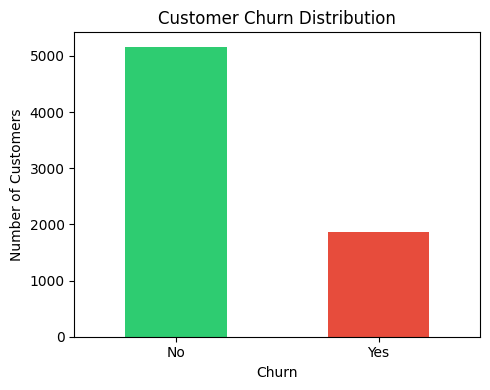

In [5]:
# Cell 5 — Explore the target column (Churn)
print("Churn value counts:")
print(df['Churn'].value_counts())
print()

print("Churn percentage:")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

# Visualise it
plt.figure(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — Prepare X and y
# Drop customerID (not a feature) and Churn (that's our target)
X = df.drop(columns=['customerID', 'Churn'])

# Target — convert Yes/No to 1/0
y = (df['Churn'] == 'Yes').astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Target distribution:")
print(y.value_counts())
print()
print("Numerical columns:")
print(X.select_dtypes(include='number').columns.tolist())
print()
print("Categorical (text) columns:")
print(X.select_dtypes(include='object').columns.tolist())

X shape: (7032, 19)
y shape: (7032,)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical (text) columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [7]:
# Cell 7 — Build the ML Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Define which columns are which type
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print()

# Step 1 — Define how to handle each column type
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),        # scale numbers
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # encode text
])

# Step 2 — Chain preprocessor + model into one Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),        # first: clean & transform data
    ('classifier', LogisticRegression(max_iter=1000))  # then: train model
])

print("Pipeline created successfully!")
print()
print("Pipeline steps:")
print(pipeline)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Pipeline created successfully!

Pipeline steps:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', '

In [8]:
# Cell 8 — Split data and train the pipeline
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y            # keep same churn ratio in both splits
)

print(f"Training set: {X_train.shape[0]} customers")
print(f"Testing set:  {X_test.shape[0]} customers")
print()

# Train the entire pipeline in ONE line!
pipeline.fit(X_train, y_train)

print("Pipeline trained successfully!")

Training set: 5625 customers
Testing set:  1407 customers

Pipeline trained successfully!


Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



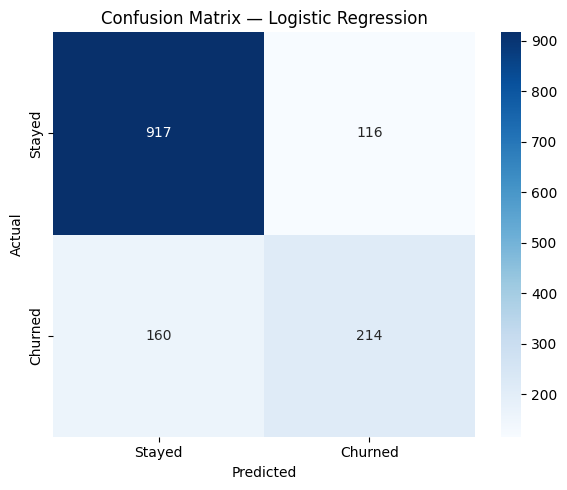

In [9]:
# Cell 9 — Evaluate the pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions
y_pred = pipeline.predict(X_test)

# Full classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [10]:
# Cell 10 — Try Random Forest in the same Pipeline
from sklearn.ensemble import RandomForestClassifier

# Same pipeline, just swap the classifier!
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluate
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned']))

Random Forest Results:
              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1033
     Churned       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [11]:
# Cell 11 — GridSearchCV to find best settings
from sklearn.model_selection import GridSearchCV

# Settings to try for Logistic Regression
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear']
}

# GridSearchCV tries all combinations with 5-fold cross validation
grid_search = GridSearchCV(
    pipeline,           # our logistic regression pipeline
    param_grid,         # settings to try
    cv=5,               # 5-fold cross validation
    scoring='f1',       # optimise for F1 score
    n_jobs=-1,          # use all CPU cores
    verbose=1
)

print("Starting GridSearch — trying all combinations...")
print(f"Total combinations: {4 * 2} settings × 5 folds = {4*2*5} runs")
print()

grid_search.fit(X_train, y_train)

print("\nBest settings found:")
print(grid_search.best_params_)
print(f"\nBest cross-validation F1: {grid_search.best_score_:.3f}")


Starting GridSearch — trying all combinations...
Total combinations: 8 settings × 5 folds = 40 runs

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best settings found:
{'classifier__C': 1, 'classifier__solver': 'liblinear'}

Best cross-validation F1: 0.596


Final Model Evaluation (Best Pipeline):
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



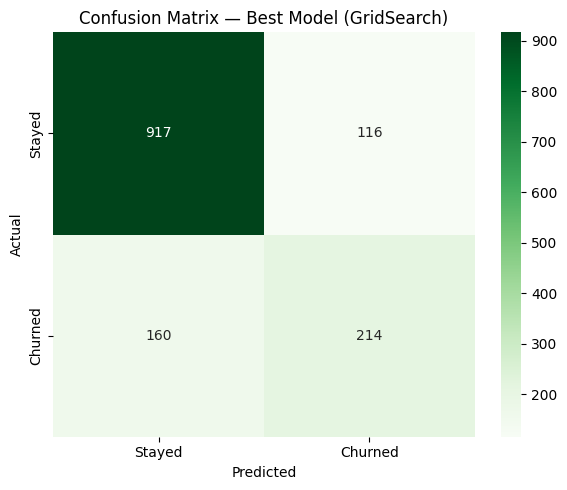

In [12]:
# Cell 12 — Evaluate the best model from GridSearch
best_pipeline = grid_search.best_estimator_

# Predict on test set
y_pred_best = best_pipeline.predict(X_test)

print("Final Model Evaluation (Best Pipeline):")
print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix — Best Model (GridSearch)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [13]:
# Cell 13 — Save the pipeline using joblib
import joblib

# Save the best pipeline to a file
joblib.dump(best_pipeline, 'churn_pipeline.pkl')
print("Pipeline saved as churn_pipeline.pkl!")
print()

# Prove it works — load it back and make a prediction
loaded_pipeline = joblib.load('churn_pipeline.pkl')
print("Pipeline loaded back successfully!")
print()

# Test on a fake new customer
new_customer = pd.DataFrame([{
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 70.35,
    'TotalCharges': 140.70
}])

prediction = loaded_pipeline.predict(new_customer)[0]
probability = loaded_pipeline.predict_proba(new_customer)[0][1]

print("New customer prediction:")
print(f"Will churn: {'YES ⚠️' if prediction == 1 else 'NO ✅'}")
print(f"Churn probability: {probability:.1%}")

Pipeline saved as churn_pipeline.pkl!

Pipeline loaded back successfully!

New customer prediction:
Will churn: YES ⚠️
Churn probability: 68.5%


In [14]:
# Cell 14 — Download the saved pipeline
from google.colab import files
files.download('churn_pipeline.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>